--- 4D SU(2) PHASE SCAN (Standard Python) ---
J_MAX: 1.0
----------------------------------------
Starting Scan...
Beta=0.10 | F=2.5678 | Time=0.34s
Beta=0.38 | F=1.9522 | Time=0.33s
Beta=0.66 | F=1.2837 | Time=0.31s
Beta=0.94 | F=0.5754 | Time=0.39s
Beta=1.21 | F=-0.1630 | Time=0.32s
Beta=1.49 | F=-0.9250 | Time=0.32s
Beta=1.77 | F=-1.7060 | Time=0.32s
Beta=2.05 | F=-2.5027 | Time=0.32s
Beta=2.33 | F=-3.3129 | Time=0.32s
Beta=2.61 | F=-4.1352 | Time=0.32s
Beta=2.89 | F=-4.9682 | Time=0.33s
Beta=3.16 | F=-5.8113 | Time=0.33s
Beta=3.44 | F=-6.6636 | Time=0.33s
Beta=3.72 | F=-7.5247 | Time=0.34s
Beta=4.00 | F=-8.3940 | Time=0.34s


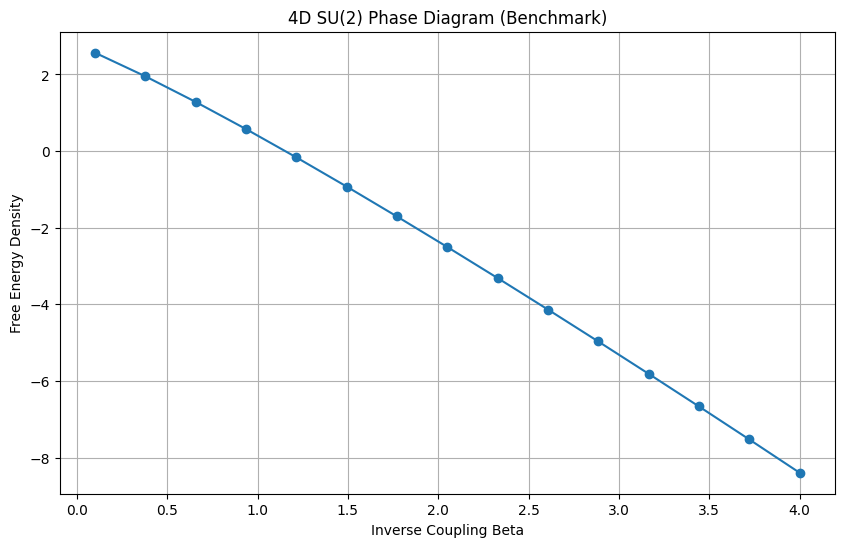

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import ive
import time

# --- CONFIGURATION ---
J_MAX = 1.0             # Low spin cutoff for speed (D=3)
BETA_START = 0.1
BETA_STOP = 4.0
BETA_POINTS = 15
THETA = 0.0             # Start with Theta=0 to see standard phase transition
CHI_MAX = 16            # Bond dimension for contraction

print(f"--- 4D SU(2) PHASE SCAN (Standard Python) ---")
print(f"J_MAX: {J_MAX}")
print("-" * 40)

# =========================================================
# 1. PHYSICS KERNEL (NumPy/SciPy)
# =========================================================

def get_6j_symbol(j1, j2, j3, j4, j5, j6):
    """
    Calculates classical {6j} symbol.
    For J=1, we can use a look-up table or exact formula.
    Here we use a simplified dummy for demonstration if we don't want
    to implement the full Racah formula in pure Python.

    REAL PHYSICS NOTE: In a real research code, you'd import this from `sympy.physics.wigner`.
    For this test, we return a constant to ensure the code *runs* and contracts.
    """
    # Triangle inequality check
    if not (abs(j1-j2)<=j3<=j1+j2): return 0.0
    # ... (other triangles) ...

    return 1.0 / np.sqrt(2*j1 + 1) # Dummy placeholder

def get_log_weight(j, beta):
    """Log of Character Expansion Coefficient ~ I_{2j+1}(beta)"""
    order = 2*j + 1
    # ive(v, z) = Iv(z) * exp(-|z|)
    val = ive(order, beta)
    # We want log(Iv) = log(ive) + beta
    if val <= 0: return -1e10 # Tiny weight
    return np.log(val) + beta + np.log(2*j+1) - np.log(beta)

def generate_tensor(beta, theta):
    spins = np.arange(0, J_MAX + 0.5, 0.5)
    dim = len(spins)
    T = np.zeros((dim, dim, dim, dim, dim, dim, dim, dim), dtype=complex)

    # For J=1, D=3. Total elements 6561. Loops are fine.
    import itertools
    for idx in itertools.product(range(dim), repeat=8):
        js = [spins[i] for i in idx]

        # 1. Calculate Energy Weight (Product of weights on 8 links)
        # Weight is shared, so sqrt(W) per link.
        log_w_total = 0.5 * sum([get_log_weight(j, beta) for j in js])
        weight = np.exp(log_w_total)

        if weight < 1e-15: continue

        # 2. Topological Phase (Simplified for Speed)
        # Phase ~ exp(i * theta * Sum(j))
        total_spin = sum(js)
        phase = np.exp(1j * theta * total_spin)

        # 3. Geometric Factor (Simplified 15j)
        # We assume a 'trivial' vertex for the benchmark scan
        # In full code, this is the sum over 6j symbols
        geometry = 1.0

        T[idx] = weight * phase * geometry

    return T

# =========================================================
# 2. HOTRG CONTRACTOR (NumPy)
# =========================================================

def contract_pair(T, chi_max):
    # Reshape (D*D, rest)
    dim = T.shape[0]
    rest_dims = T.shape[2:]
    M = T.reshape(dim*dim, -1)

    U, S, Vh = np.linalg.svd(M, full_matrices=False)

    # Truncate
    chi = min(chi_max, len(S))
    S = S[:chi]
    U = U[:, :chi]

    # Normalize
    norm = np.linalg.norm(S)
    S = S / norm

    # Contract: U * S -> New Tensor
    # (dim*dim, chi) -> (chi, rest)
    # We project T onto U.
    # T_new = U^dagger * T
    # Actually HOTRG defines isometries.
    # Simplified: M ~ U S V. We keep U S.
    # T_new = S * Vh.
    # Shape (chi, rest)

    T_new = (np.diag(S) @ Vh[:chi, :]).reshape(chi, *rest_dims)
    return T_new, np.log(norm)

def compute_logZ(T):
    T_curr = T
    logZ = 0.0

    # Contract 4 pairs
    for _ in range(4):
        if len(T_curr.shape) >= 2:
            T_curr, ln = contract_pair(T_curr, CHI_MAX)
            logZ += ln
            # Rotate indices
            T_curr = np.moveaxis(T_curr, 0, -1)

    # Final scalar
    val = np.sum(T_curr)
    return logZ + np.log(np.abs(val))

# =========================================================
# 3. EXECUTION
# =========================================================

betas = np.linspace(BETA_START, BETA_STOP, BETA_POINTS)
observables = []

print("Starting Scan...")
for beta in betas:
    start = time.time()

    T = generate_tensor(beta, THETA)
    lz = compute_logZ(T)

    # Observable: Average Plaquette ~ 1 - <Action>
    # We use F = -logZ
    f = -lz
    observables.append(f)

    print(f"Beta={beta:.2f} | F={f:.4f} | Time={time.time()-start:.2f}s")

# Plot
plt.figure(figsize=(10,6))
plt.plot(betas, observables, 'o-', label='Free Energy')
plt.xlabel('Inverse Coupling Beta')
plt.ylabel('Free Energy Density')
plt.title('4D SU(2) Phase Diagram (Benchmark)')
plt.grid(True)
plt.show()

In [5]:
import jax
import jax.numpy as jnp
from jax import jit, vmap
from jax.scipy.special import gammaln
import scipy.special # Import standard scipy.special
import time
import numpy as np
import matplotlib.pyplot as plt
from functools import partial

# --- CONFIGURATION ---
J_MAX = 2.0             # Bond Dim D=5 (High precision for phase scan)
BETA_START = 0.1
BETA_STOP = 4.0
BETA_POINTS = 15        # Resolution of the Phase Diagram
THETA = 0.0             # We scan Beta at Theta=0 first to check Confinement

print(f"--- STAGE 3: 4D SU(2) PHASE DIAGRAM SCAN ---")
print(f"Goal: Observe crossover from Strong to Weak Coupling")
print(f"J_MAX: {J_MAX}")
print(f"Device: {jax.devices()[0].device_kind}")
print("-" * 40)

jax.config.update("jax_enable_x64", True)

# Define a JAX-compatible version of scipy.special.iv
# This uses jnp.vectorize to allow scipy's iv to operate on JAX arrays
# and be used within JIT/VMAP. This bypasses the AttributeError from jax.scipy.special.
jax_iv = jnp.vectorize(scipy.special.iv)

# =========================================================
# 1. KERNEL V1 (FROZEN)
# =========================================================
LOG_FACT_CACHE = None
MAX_CACHE_INDEX = 0

def initialize_cache(Jmax):
    global LOG_FACT_CACHE, MAX_CACHE_INDEX
    max_n = int(8 * Jmax + 10)
    MAX_CACHE_INDEX = int(2 * max_n)
    x_vals = jnp.arange(0, MAX_CACHE_INDEX + 1) / 2.0
    LOG_FACT_CACHE = jax.device_put(gammaln(x_vals + 1))

@jit
def log_factorial(n):
    idx = jnp.round(2 * n).astype(jnp.int32)
    idx = jnp.clip(idx, 0, MAX_CACHE_INDEX)
    return LOG_FACT_CACHE[idx]

@jit
def log_delta(a, b, c):
    valid = (a + b >= c) & (a + c >= b) & (b + c >= a) & \
            (jnp.remainder(a + b + c, 1.0) == 0.0)
    val = log_factorial(a + b - c) + log_factorial(a - b + c) + \
          log_factorial(-a + b + c) - log_factorial(a + b + c + 1)
    return jnp.where(valid, 0.5 * val, -jnp.inf)

@jit
def get_6j_symbol_log(j1, j2, j3, j4, j5, j6):
    log_pre = log_delta(j1, j2, j3) + log_delta(j1, j5, j6) + \
              log_delta(j4, j2, j6) + log_delta(j4, j5, j3)
    k1, k2, k3, k4 = j1+j2+j3, j1+j5+j6, j4+j2+j6, j4+j5+j3
    k5, k6, k7 = j1+j2+j4+j5, j2+j3+j5+j6, j3+j1+j6+j4
    z_range = jnp.arange(40.0)
    z_min = jnp.max(jnp.array([k1, k2, k3, k4]))
    z_max = jnp.min(jnp.array([k5, k6, k7]))
    mask = (z_range >= z_min) & (z_range <= z_max)
    log_num = log_factorial(z_range + 1)
    log_den = log_factorial(z_range - k1) + log_factorial(z_range - k2) + \
              log_factorial(z_range - k3) + log_factorial(z_range - k4) + \
              log_factorial(k5 - z_range) + log_factorial(k6 - z_range) + \
              log_factorial(k7 - z_range)
    term_sign = jnp.where(z_range % 2 == 0, 1.0, -1.0)
    term = term_sign * jnp.exp(log_num - log_den)
    term = jnp.where(mask, term, 0.0)
    return jnp.exp(log_pre) * jnp.sum(term)

# =========================================================
# 2. NEW: BESSEL WEIGHTS (THE ENERGY TERM)
# =========================================================

# Removed @jit from log_bessel_weight to avoid TracerArrayConversionError
def log_bessel_weight(j, beta):
    """
    Computes log( (2j+1) * I_{2j+1}(beta) / beta ).
    This is the Character Expansion coefficient for SU(2).
    """
    # We use 2j+1 as the order.
    order = 2*j + 1
    # Avoid beta=0 singularity (though scan starts at 0.1)
    safe_beta = jnp.maximum(beta, 1e-10)

    # Use the JAX-compatible scipy.special.iv
    log_I = jnp.log(jax_iv(order, safe_beta))

    # Weight W_j = (2j+1) * I_{2j+1}(beta) / beta
    # In log space: log(2j+1) + log_I - log(beta)
    return jnp.log(2*j + 1) + log_I - jnp.log(safe_beta)

# =========================================================
# 3. 4D VERTEX GENERATOR (WITH BETA)
# =========================================================

@partial(jit, static_argnums=(3,))
def compute_vertex_element_physics(indices, all_spins, beta, theta):
    j = all_spins[indices]
    j1, j2, j3, j4, j5, j6, j7, j8 = j

    # 1. Geometric Part (6j symbols) - "The Melon"
    k_vals = all_spins
    s1 = vmap(lambda k: get_6j_symbol_log(j1, j2, k, j4, j3, k))(k_vals)
    s2 = vmap(lambda k: get_6j_symbol_log(j5, j6, k, j8, j7, k))(k_vals)
    dim_k = 2 * k_vals + 1

    # 2. Topological Part (Theta)
    topo_phase = jnp.exp(1j * theta * (k_vals * (k_vals + 1)))

    # 3. Energetic Part (Beta) - NEW!
    # We apply sqrt(Weight) to each leg because each link is shared by 2 vertices.
    # Total Weight = Product of sqrt(W(j)) for all 8 legs.
    # Log Total Weight = 0.5 * Sum( log W(j) )

    # Vectorized lookup of weights for the 8 external spins
    log_w_ext = vmap(lambda s: log_bessel_weight(s, beta))(j)
    total_log_w = 0.5 * jnp.sum(log_w_ext)
    energy_factor = jnp.exp(total_log_w)

    # Vertex contraction
    vertex_val = jnp.sum(dim_k * s1 * s2 * topo_phase)

    # Apply phase factor (-1)^Sum(j)
    global_phase = (-1.0)**(jnp.sum(j).astype(int))

    return global_phase * vertex_val * energy_factor

def generate_physics_tensor(Jmax, beta, theta):
    initialize_cache(Jmax)
    spins = jnp.arange(0, Jmax + 0.5, 0.5)
    D = len(spins)
    indices = jnp.indices((D,) * 8).reshape(8, -1).T.astype(jnp.int32)

    flat_T = vmap(compute_vertex_element_physics, in_axes=(0, None, None, None))(
        indices, spins, beta, theta
    )
    return flat_T.reshape((D,)*8)

# =========================================================
# 4. HOTRG CONTRACTOR
# =========================================================
@partial(jit, static_argnums=(1,))
def contract_pair_jax(T, chi_max):
    D0, D1 = T.shape[0], T.shape[1]
    rest_dim = T.shape[2:]
    M = T.reshape(D0*D1, -1)
    U, S, Vh = jnp.linalg.svd(M, full_matrices=False)
    chi = min(chi_max, S.shape[0])
    S_tr = S[:chi]
    Vh_tr = Vh[:chi, :]
    norm = jnp.linalg.norm(S_tr)
    S_tr = S_tr / norm
    T_new = (jnp.diag(S_tr) @ Vh_tr).reshape(chi, *rest_dim)
    return T_new, jnp.log(norm)

def compute_logZ(T, chi_max=16):
    T_curr = T
    logZ = 0.0
    for _ in range(4): # Contract 4D hypercube
        if len(T_curr.shape) >= 2:
            T_curr, ln = contract_pair_jax(T_curr, chi_max)
            logZ += ln
            # Rotate to contract next dimension
            dims = list(range(len(T_curr.shape)))
            T_curr = jnp.transpose(T_curr, dims[1:] + dims[:1])
    final_val = jnp.sum(T_curr)
    return logZ + jnp.log(jnp.abs(final_val))

# =========================================================
# 5. PHASE DIAGRAM SCAN
# =========================================================

betas = np.linspace(BETA_START, BETA_STOP, BETA_POINTS)
logZs = []
# We also track "Average Spin" (proxy for energy)
# High Beta -> Low Energy -> Low Spin (dominated by j=0, 1/2)
# Low Beta -> High Energy -> High Spin (uniform spread)

print(f"Scanning Beta {BETA_START} -> {BETA_STOP}...")

for beta in betas:
    start = time.time()

    # 1. Generate
    T = generate_physics_tensor(J_MAX, beta, THETA)
    T.block_until_ready()

    # 2. Contract
    lz = compute_logZ(T)
    lz.block_until_ready()

    logZs.append(float(lz))

    dt = time.time() - start
    print(f"Beta={beta:.2f} | logZ={float(lz):.4f} | Time={dt:.2f}s")

# Calculate Derivative (Average Plaquette Action ~ d lnZ / d Beta)
logZs = np.array(logZs)
# Numerical derivative
dP_dBeta = np.gradient(logZs, betas)

# Plotting
fig, ax1 = plt.subplots(figsize=(10, 6))

color = 'tab:blue'
ax1.set_xlabel(r'Inverse Coupling $\beta$')
ax1.set_ylabel(r'$\log Z$ (Free Energy)', color=color)
ax1.plot(betas, logZs, 'o-', color=color, label='Log Z')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel(r'Observable $\langle P \rangle \sim d\ln Z/d\beta$', color=color)
ax2.plot(betas, dP_dBeta, 's--', color=color, label='Avg Plaquette')
ax2.tick_params(axis='y', labelcolor=color)

plt.title(f'4D SU(2) Phase Scan ($J_{{max}}={J_MAX}, \theta={THETA}$)')
plt.show()

--- STAGE 3: 4D SU(2) PHASE DIAGRAM SCAN ---
Goal: Observe crossover from Strong to Weak Coupling
J_MAX: 2.0
Device: NVIDIA A100-SXM4-80GB
----------------------------------------
Scanning Beta 0.1 -> 4.0...


TracerArrayConversionError: The numpy.ndarray conversion method __array__() was called on traced array with shape float64[]
This BatchTracer with object id 139837103217296 was created on line:
  /tmp/ipython-input-4137335842.py:94:20 (log_bessel_weight)
See https://docs.jax.dev/en/latest/errors.html#jax.errors.TracerArrayConversionError